# UK interest rates across time and maturity with GeDS

This notebook introduces the Python interface to [GeDS](https://github.com/emilioluissaenzguillen/GeDS) through two examples: a one-dimensional fit to the UK 10-year nominal spot rate, and a joint time–maturity surface fitted to sparse tenor data. In the second example we hide four published maturities throughout each period, display the surfaces fitted from the remaining four, and check how accurately they reconstruct the hidden rates. GeDS fits the curves and surfaces through its R implementation; Python handles data preparation and visualisation.

The source is the Bank of England's [monthly government nominal yield-curve archive](https://www.bankofengland.co.uk/statistics/yield-curves). These are **already estimated zero-coupon spot rates**, not raw gilt prices. We are describing published rates, not replacing the Bank's curve-construction method or forecasting future rates. The source archive can be revised; results may change if the Bank updates it. Rates below are in percentage points. For a fuller introduction to GeDS itself, see the [GeDS R vignette](https://cran.r-project.org/web/packages/GeDS/vignettes/rpubs_GeDS.html).

## Setup

Install R and the compatible GeDS 0.3.6 GitHub build as described in the [package README](https://github.com/emilioluissaenzguillen/GeDS-python#requirements). In your Python environment, run `python -m pip install "geds-python[plot]" openpyxl notebook`. Run `python -m geds.check` if GeDS cannot find R. The data download requires internet access.

In [286]:
from io import BytesIO
from urllib.request import Request, urlopen
from zipfile import ZipFile

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from geds import GeDSRegressor

COLOR_GEDS = '#C43C39'
COLOR_BASELINE = '#2B7BBA'
COLOR_OBSERVED = '#263238'
COLOR_TENOR_GUIDE = '#60676D'
COLOR_MATURITY_KNOT = '#6A51A3'
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlelocation': 'left', 'axes.titlesize': 13,
    'font.size': 10, 'figure.dpi': 110,
})

ARCHIVE_URL = (
    'https://www.bankofengland.co.uk/-/media/boe/files/statistics/'
    'yield-curves/glcnominalmonthedata.zip'
)
WORKBOOK = 'GLC Nominal month end data_2016 to 2024.xlsx'
START, END = '2020-01-01', '2024-12-31'
MATURITIES = [2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 15.0, 20.0]

request = Request(ARCHIVE_URL, headers={'User-Agent': 'Mozilla/5.0'})
with urlopen(request, timeout=60) as response:
    archive_bytes = response.read()
with ZipFile(BytesIO(archive_bytes)) as archive:
    with archive.open(WORKBOOK) as workbook:
        sheet = pd.read_excel(workbook, sheet_name='4. spot curve', header=None)

maturity_headers = pd.to_numeric(sheet.iloc[3, 1:], errors='coerce')
columns = [int(np.argmin(abs(maturity_headers.to_numpy() - m))) + 1 for m in MATURITIES]
assert all(abs(float(maturity_headers.iloc[c - 1]) - m) < 1e-6
           for c, m in zip(columns, MATURITIES))
wide = sheet.iloc[5:, [0, *columns]].copy()
wide.columns = ['date', *MATURITIES]
wide['date'] = pd.to_datetime(wide['date'], errors='coerce')
all_wide = wide.set_index('date').sort_index()
all_wide = all_wide.apply(pd.to_numeric, errors='coerce')
all_wide = all_wide.dropna(subset=MATURITIES)
wide = all_wide.loc[START:END].copy()
assert len(wide) == 60 and wide.index.is_unique, 'Check the source layout or missing months.'
print(f'{len(wide)} month-end curves from {wide.index.min():%Y-%m} to {wide.index.max():%Y-%m}')
wide.head()

60 month-end curves from 2020-01 to 2024-12


,2.0,4.0,6.0,8.0,10.0,12.0,15.0,20.0
date,,,,,,,,
2020-01-31,0.461198,0.384557,0.383277,0.434188,0.529469,0.649506,0.829145,1.032807
2020-02-29,0.335304,0.284427,0.289024,0.339662,0.433091,0.551954,0.732943,0.943352
2020-03-31,0.139571,0.152894,0.180457,0.249627,0.361595,0.494341,0.678474,0.864182
2020-04-30,0.034725,0.046292,0.083063,0.149969,0.243850,0.347614,0.483587,0.611948
2020-05-31,-0.026463,-0.047483,-0.010422,0.072939,0.184513,0.301683,0.452836,0.604871


## 1. One maturity: the 10-year rate over time

We first hold maturity fixed at ten years. `order=3` means a **quadratic spline (polynomial degree 2)** in GeDS terminology; it does not mean a cubic spline. A **knot** is a place where spline pieces join. GeDS builds its fit by inserting knots adaptively, giving the fitted line room to bend where the historical series changes shape. Short red marks beneath the curve show internal knot dates without obscuring the rates. This is descriptive smoothing, not a prediction of next month's yield.

Internal knots: 21


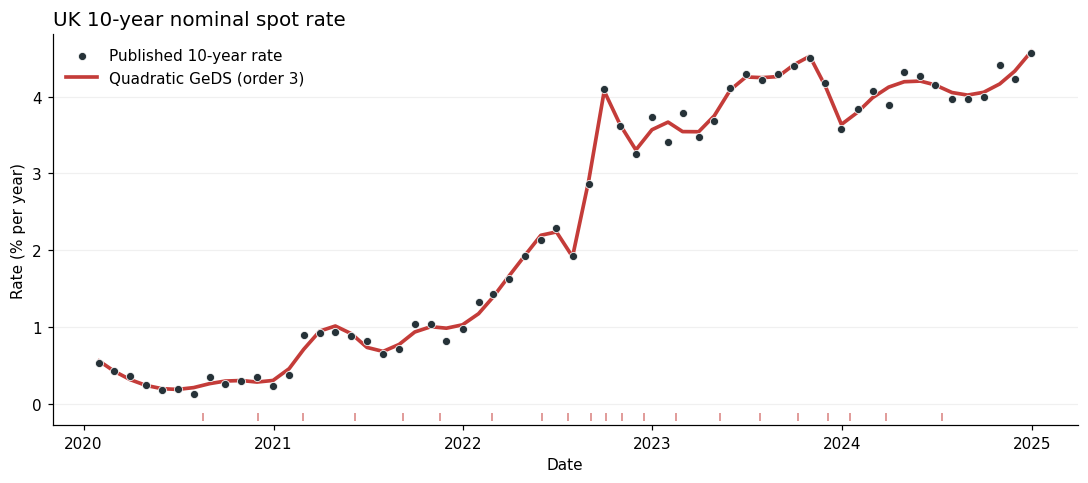

In [288]:
origin = wide.index.min()
time_years = (wide.index - origin).days.to_numpy() / 365.25
X_10y = pd.DataFrame({'time_years': time_years})
model_10y = GeDSRegressor(order=3).fit(X_10y, wide[10.0].to_numpy())
fitted_10y = model_10y.predict(X_10y)
knots_10y = np.asarray(model_10y.knots_, dtype=float).ravel()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.scatter(wide.index, wide[10.0], s=28, color=COLOR_OBSERVED,
           edgecolor='white', linewidth=0.5, zorder=3, label='Published 10-year rate')
ax.plot(wide.index, fitted_10y, color=COLOR_GEDS, lw=2.4,
        label='Quadratic GeDS (order 3)')
lower, upper = ax.get_ylim()
ax.set_ylim(lower - 0.18, upper)
for knot in knots_10y:
    ax.vlines(origin + pd.to_timedelta(knot * 365.25, unit='D'),
              lower - 0.12, lower - 0.02, color=COLOR_GEDS, alpha=0.65, lw=1)
ax.set(title='UK 10-year nominal spot rate',
       ylabel='Rate (% per year)', xlabel='Date')
ax.grid(axis='y', alpha=0.18)
ax.legend(frameon=False, loc='upper left')
fig.tight_layout()
print(f'Internal knots: {len(knots_10y)}')
plt.show()

## 2. Reconstructing a yield surface from four maturities

For **each month**, we supply GeDS with the published 2-, 6-, 10-, and 20-year spot rates. We keep the 4-, 8-, 12-, and 15-year rates hidden for checking later. A single bivariate GeDS model then fits all supplied date–maturity–rate rows **together**, yielding one surface for 2016–2019 (48 months × 4 rates = 192 training rows) and a separate surface for 2020–2024 (60 months × 4 = 240 rows). The four hidden maturities are absent throughout each period, not merely in selected months.

The two inputs are time and maturity. We use `order=3` (quadratic in each input). As GeDS inserts knots, a **stopping rule** decides when to stop adding them: `stop_type='SR'` selects the smoothed-ratio rule, and `phi=0.995` is its threshold. Under SR, a higher `phi` generally permits more knots. These settings and the tenor choices are exploratory. The surfaces below are the **same fitted models** used in the accuracy comparison; neither model has seen the hidden rates. Four dotted black lines on each base plane mark the **maturities used for fitting** throughout the period; they are guides, not fitted rate curves. Colours share one rate scale, but the vertical axes use each period's range to keep both shapes legible.

In [290]:
OBSERVED_TENORS = [2.0, 6.0, 10.0, 20.0]
HIDDEN_TENORS = [m for m in MATURITIES if m not in OBSERVED_TENORS]
features = ['time_years', 'maturity_years']

def reconstruct_missing_tenors(curves):
    tidy = curves.rename_axis('date').reset_index().melt(
        id_vars='date', var_name='maturity_years', value_name='yield_pct'
    )
    tidy['maturity_years'] = tidy['maturity_years'].astype(float)
    tidy['time_years'] = (tidy['date'] - curves.index.min()).dt.days / 365.25
    observed = tidy['maturity_years'].isin(OBSERVED_TENORS)
    known, hidden = tidy.loc[observed], tidy.loc[~observed].copy()
    model = GeDSRegressor(
        spline_features=features, order=3, stop_type='SR', phi=0.995
    ).fit(known[features], known['yield_pct'])
    hidden['geds'] = model.predict(hidden[features])
    hidden['linear'] = [
        np.interp(m, OBSERVED_TENORS, curves.loc[d, OBSERVED_TENORS].to_numpy(dtype=float))
        for d, m in zip(hidden['date'], hidden['maturity_years'])
    ]
    return hidden, model

earlier_curves = all_wide.loc['2016-01-01':'2019-12-31']
assert len(earlier_curves) == 48, 'Check the archive or missing months.'
earlier_hidden, earlier_surface = reconstruct_missing_tenors(earlier_curves)
recent_hidden, sparse_surface = reconstruct_missing_tenors(wide)
print(f'2016–2019: {len(earlier_curves) * len(OBSERVED_TENORS)} training rates; '
      f'{len(earlier_hidden)} hidden rates.')
print(f'2020–2024: {len(wide) * len(OBSERVED_TENORS)} training rates; '
      f'{len(recent_hidden)} hidden rates.')

2016–2019: 192 training rates; 192 hidden rates.
2020–2024: 240 training rates; 240 hidden rates.


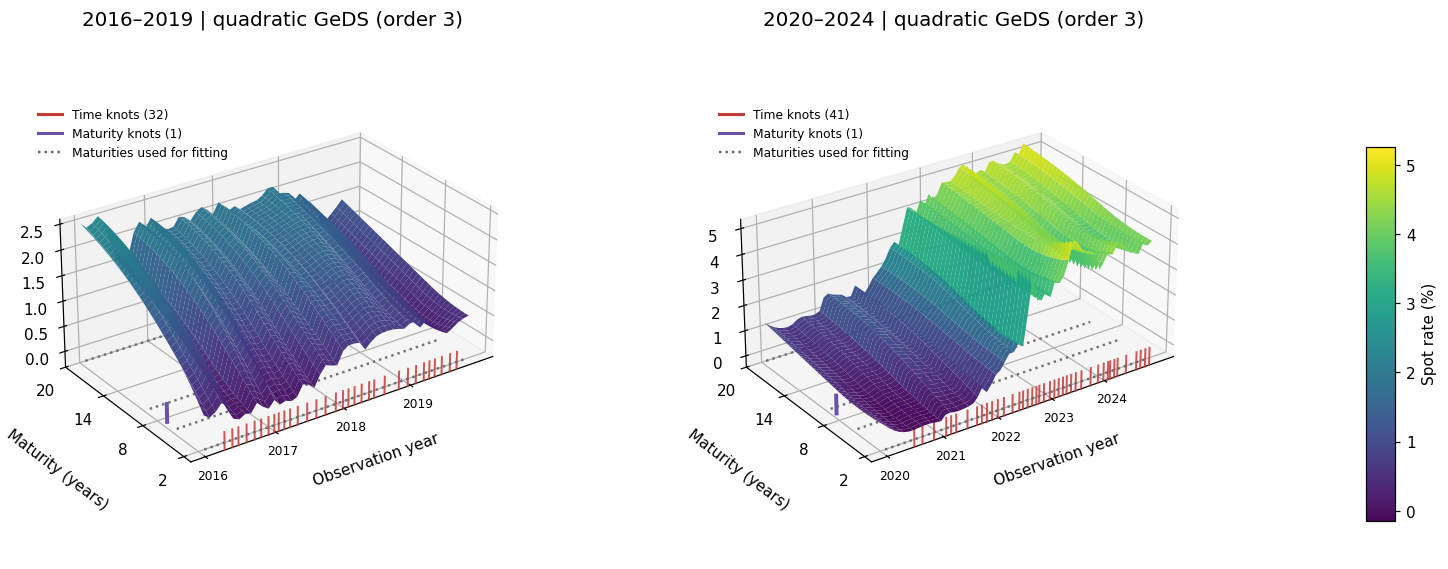

In [291]:
periods = [
    ('2016–2019', earlier_curves, earlier_surface),
    ('2020–2024', wide, sparse_surface),
]
rate_min = min(curves.min().min() for _, curves, _ in periods)
rate_max = max(curves.max().max() for _, curves, _ in periods)
display_maturities = np.linspace(min(MATURITIES), max(MATURITIES), 37)

fig = plt.figure(figsize=(16.5, 6.8))
axes = [fig.add_subplot(1, 2, i, projection='3d') for i in (1, 2)]
for ax, (label, curves, model) in zip(axes, periods):
    period_origin = curves.index.min()
    period_time = (curves.index - period_origin).days.to_numpy() / 365.25
    year_start = period_origin.year + (period_origin.dayofyear - 1) / 365.25
    grid_time, grid_maturity = np.meshgrid(
        period_time, display_maturities, indexing='ij'
    )
    grid = pd.DataFrame({
        'time_years': grid_time.ravel(),
        'maturity_years': grid_maturity.ravel(),
    })
    grid_yields = model.predict(grid).reshape(grid_time.shape)
    surface_plot = ax.plot_surface(
        year_start + grid_time, grid_maturity, grid_yields,
        cmap='viridis', vmin=rate_min, vmax=rate_max,
        linewidth=0, antialiased=True, alpha=0.97,
    )
    time_knots = np.asarray(model.knots_['Xk'], dtype=float)
    maturity_knots = np.asarray(model.knots_['Yk'], dtype=float)
    z_floor = float(grid_yields.min()) - 0.35
    stick_height = 0.12 * (float(grid_yields.max()) + 0.15 - z_floor)
    for knot in time_knots:
        ax.plot([year_start + knot] * 2, [1.0] * 2,
                [z_floor, z_floor + stick_height],
                color=COLOR_GEDS, lw=1.3, alpha=0.85)
    for knot in maturity_knots:
        ax.plot([year_start] * 2, [knot] * 2,
                [z_floor, z_floor + stick_height],
                color=COLOR_MATURITY_KNOT, lw=2.6)
    for tenor in OBSERVED_TENORS:
        ax.plot([year_start, year_start + period_time[-1]], [tenor] * 2,
                [z_floor] * 2, color=COLOR_TENOR_GUIDE, ls=':', lw=1.6, alpha=0.9)
    ax.view_init(elev=27, azim=-125)
    ax.set(title=f'{label} | quadratic GeDS (order 3)',
           xlabel='Observation year', ylabel='Maturity (years)')
    ax.xaxis.labelpad = 17
    ax.yaxis.labelpad = 18
    ax.set_ylim(1, max(MATURITIES))
    ax.set_yticks([2, 8, 14, 20])
    ax.set_zlim(z_floor, float(grid_yields.max()) + 0.15)
    ax.set_xticks(list(range(curves.index.min().year, curves.index.max().year + 1)))
    ax.tick_params(axis='x', labelsize=8, pad=1)
    ax.set_box_aspect((1.6, 1, 0.72), zoom=0.86)
    ax.legend(handles=[
        Line2D([0], [0], color=COLOR_GEDS, lw=2,
               label=f'Time knots ({len(time_knots)})'),
        Line2D([0], [0], color=COLOR_MATURITY_KNOT, lw=2,
               label=f'Maturity knots ({len(maturity_knots)})'),
        Line2D([0], [0], color=COLOR_TENOR_GUIDE, ls=':', lw=1.6,
               label='Maturities used for fitting'),
    ], loc='upper left', bbox_to_anchor=(0.03, 0.88), fontsize=8, frameon=False)

fig.subplots_adjust(left=0.15, right=0.86, bottom=0.2, top=0.9, wspace=0.12)
colorbar_axis = fig.add_axes([0.92, 0.25, 0.016, 0.5])
fig.colorbar(surface_plot, cax=colorbar_axis, label='Spot rate (%)')
plt.show()

### Check against the hidden published rates

For every month, we predict its four withheld maturities from the corresponding fitted GeDS surface and compare them with the published values that were kept out of fitting. The baseline instead draws straight lines between the four observed rates **within that month**. Thus both methods are denied the hidden values, but GeDS also uses the observed rates from *other months*; this is not an equal-information comparison.

The table reports mean absolute error (MAE) in percentage points, separately for the two periods. The July 2022 plot shows the full published curve in black **only so we can check the estimates**. Open black rings mark the four rates supplied to the methods (2, 6, 10, and 20 years); the other four black points (4, 8, 12, and 15 years) were withheld from fitting. The red GeDS curve comes from the 2020–2024 surface, while the dashed blue curve linearly joins that month's four supplied rates. We score errors **only at the four withheld maturities**. This is within-period maturity interpolation, not a forward-in-time forecasting test. The exploratory settings and two historical periods do not establish a general performance guarantee.

MAE in percentage points; each period withholds four maturities per month:
           GeDS MAE  Linear MAE
2016–2019     0.029       0.044
2020–2024     0.030       0.045

2016–2019 MAE by withheld maturity:
                 geds  linear
maturity_years               
4.0             0.028   0.024
8.0             0.024   0.014
12.0            0.027   0.053
15.0            0.037   0.085
Internal knots: {'Xk': 32, 'Yk': 1}

2020–2024 MAE by withheld maturity:
                 geds  linear
maturity_years               
4.0             0.031   0.051
8.0             0.025   0.020
12.0            0.027   0.039
15.0            0.037   0.070
Internal knots: {'Xk': 41, 'Yk': 1}


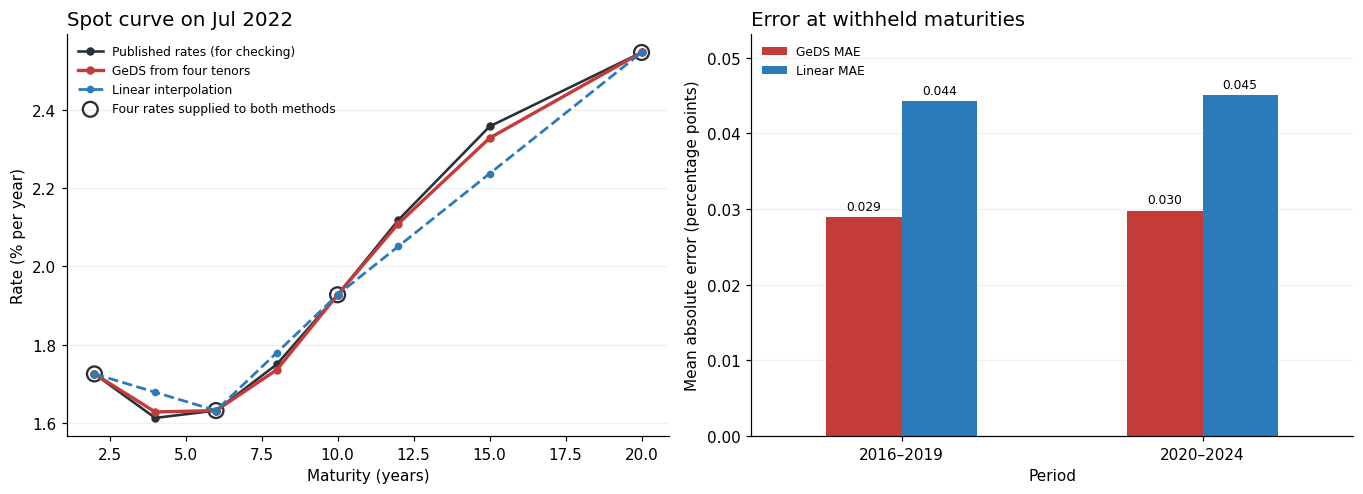

In [295]:
def mean_absolute_errors(hidden):
    return {name: np.mean(abs(hidden['yield_pct'] - hidden[name]))
            for name in ('geds', 'linear')}

comparison = pd.DataFrame({
    '2016–2019': mean_absolute_errors(earlier_hidden),
    '2020–2024': mean_absolute_errors(recent_hidden),
}).T.rename(columns={'geds': 'GeDS MAE', 'linear': 'Linear MAE'})

print('MAE in percentage points; each period withholds four maturities per month:')
print(comparison.round(3).to_string())
for period, hidden, model in (
    ('2016–2019', earlier_hidden, earlier_surface),
    ('2020–2024', recent_hidden, sparse_surface),
):
    print(f'\n{period} MAE by withheld maturity:')
    print(hidden.groupby('maturity_years').apply(
        lambda rows: pd.Series(mean_absolute_errors(rows)),
        include_groups=False
    ).round(3).to_string())
    print('Internal knots:',
          {axis: 0 if knots is None else len(knots)
           for axis, knots in model.knots_.items()})

display_date = wide.index[len(wide) // 2]  # A fixed, middle-of-sample illustration.
display_X = pd.DataFrame({
    'time_years': [(display_date - wide.index.min()).days / 365.25] * len(MATURITIES),
    'maturity_years': MATURITIES,
})
fig, (ax_curve, ax_error) = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax_curve.plot(MATURITIES, wide.loc[display_date, MATURITIES], 'o-',
              color=COLOR_OBSERVED, lw=1.7, ms=4.5, label='Published rates (for checking)')
ax_curve.plot(MATURITIES, sparse_surface.predict(display_X), 'o-',
              color=COLOR_GEDS, lw=2.2, ms=4.5, label='GeDS from four tenors')
ax_curve.plot(MATURITIES, np.interp(MATURITIES, OBSERVED_TENORS,
              wide.loc[display_date, OBSERVED_TENORS]), 'o--',
              color=COLOR_BASELINE, lw=1.8, ms=4, label='Linear interpolation')
ax_curve.scatter(OBSERVED_TENORS, wide.loc[display_date, OBSERVED_TENORS],
                 s=95, facecolors='none', edgecolors=COLOR_OBSERVED, linewidths=1.5,
                 label='Four rates supplied to both methods')
ax_curve.set(title=f'Spot curve on {display_date:%b %Y}',
             xlabel='Maturity (years)', ylabel='Rate (% per year)')
ax_curve.grid(axis='y', alpha=0.18)
ax_curve.legend(fontsize=8, frameon=False)
comparison.plot.bar(ax=ax_error, rot=0, color=[COLOR_GEDS, COLOR_BASELINE])
ax_error.set(title='Error at withheld maturities',
             ylabel='Mean absolute error (percentage points)', xlabel='Period')
ax_error.set_ylim(0, comparison.to_numpy().max() * 1.18)
for bars in ax_error.containers:
    ax_error.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax_error.grid(axis='y', alpha=0.18)
ax_error.set_axisbelow(True)
ax_error.legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

## Interpretation and limits

These are the **two sparse-tenor surfaces** that generate the reconstruction results above. Red sticks at the illustrative 1-year position mark internal **time** knots, separated from the 2-year fitted-maturity guide; purple sticks mark internal **maturity** knots; four dotted black lines mark the maturities used to fit each model. The sticks and dotted lines sit on the base planes for visibility rather than on the fitted surfaces. The models are fitted only over the 2–20-year maturity range: the 1-year position is a display guide, not a fitted rate. With this exploratory `phi=0.995` setting, GeDS has lower **average** missing-maturity error in both periods, but not at every individual maturity. The many time knots and fitted shapes are properties of this sample and setting, not economically identified regime breaks.

This is not a pricing, trading, or forecasting model. GeDS does not impose absence of arbitrage on the fitted term structure, and the Bank's inputs are themselves fitted curves. Avoid extrapolating beyond the observed dates or maturity range. See the Bank's [methodology notes](https://www.bankofengland.co.uk/statistics/yield-curves/terminology-and-concepts) for how its curves are constructed.